# Smart Mobility & Ride Analytics

## Module-End Project

### Objective

This project analyzes ride-hailing data using mathematical,
probabilistic, statistical, and inferential techniques.

### Analysis Areas

- Data Preparation
- Linear Algebra
- Probability
- Descriptive Statistics
- Outlier Detection
- Correlation and Covariance
- Inferential Statistics
- Hypothesis Testing
- Business Insights

### Dataset

This project uses a synthetic ride-hailing dataset created for
academic analysis because the official Trip_Analysis dataset was
not available in the provided course materials.

The dataset contains 120 ride records and includes trip distance,
fare amount, ride category, surge pricing, customer ratings,
peak-hour status, revenue, demand, wait time, driver rating,
and cancellation rate.

In [27]:
#Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_1samp,
    ttest_ind,
    ttest_rel,
    chi2_contingency,
    f_oneway,
    norm
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [28]:
# Load dataset

df = pd.read_csv("/content/Trip_Analysis.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (120, 12)


,TripID,TripDistance,FareAmount,RideCategory,SurgePricing,CustomerRating,PeakHour,Revenue,RideDemand,WaitTime,DriverRating,CancellationRate
0,1001,20.99,98.23,Premium,1.75,4.06,Non-Peak,103.11,46,9.8,4.68,0.046
1,1002,20.23,43.15,Economy,1.00,4.57,Non-Peak,42.83,53,6.4,4.15,0.031
2,1003,6.97,10.04,Shared,1.00,4.35,Peak,17.87,143,6.6,4.81,0.000
3,1004,13.97,43.26,Premium,1.00,4.85,Peak,54.41,115,4.4,4.31,0.039
4,1005,15.74,47.70,Economy,1.25,5.00,Peak,52.77,66,8.8,4.74,0.051


In [29]:
# Basic data inspection

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (120, 12)

Columns:
['TripID', 'TripDistance', 'FareAmount', 'RideCategory', 'SurgePricing', 'CustomerRating', 'PeakHour', 'Revenue', 'RideDemand', 'WaitTime', 'DriverRating', 'CancellationRate']

Data Types:
TripID                int64
TripDistance        float64
FareAmount          float64
RideCategory         object
SurgePricing        float64
CustomerRating      float64
PeakHour             object
Revenue             float64
RideDemand            int64
WaitTime            float64
DriverRating        float64
CancellationRate    float64
dtype: object

Missing Values:
TripID              0
TripDistance        0
FareAmount          0
RideCategory        0
SurgePricing        0
CustomerRating      0
PeakHour            0
Revenue             0
RideDemand          0
WaitTime            0
DriverRating        0
CancellationRate    0
dtype: int64

Duplicate Rows:
0


In [30]:
# Display the complete dataset

display(df)

,TripID,TripDistance,FareAmount,RideCategory,SurgePricing,CustomerRating,PeakHour,Revenue,RideDemand,WaitTime,DriverRating,CancellationRate
0,1001,20.99,98.23,Premium,1.75,4.06,Non-Peak,103.11,46,9.8,4.68,0.046
1,1002,20.23,43.15,Economy,1.00,4.57,Non-Peak,42.83,53,6.4,4.15,0.031
2,1003,6.97,10.04,Shared,1.00,4.35,Peak,17.87,143,6.6,4.81,0.000
3,1004,13.97,43.26,Premium,1.00,4.85,Peak,54.41,115,4.4,4.31,0.039
4,1005,15.74,47.70,Economy,1.25,5.00,Peak,52.77,66,8.8,4.74,0.051
...,...,...,...,...,...,...,...,...,...,...,...,...
115,1116,13.78,38.66,Shared,1.00,4.00,Non-Peak,38.36,72,6.1,4.63,0.051
116,1117,19.45,69.56,Premium,1.10,4.35,Non-Peak,71.38,71,4.1,4.80,0.021
117,1118,20.28,65.57,Premium,1.10,4.36,Non-Peak,69.45,43,6.1,4.08,0.067
118,1119,13.07,43.65,Economy,1.25,4.51,Peak,48.23,125,5.8,4.35,0.055


In [31]:
# Data cleaning

print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows before cleaning:")
print(df.duplicated().sum())

Missing values before cleaning:
TripID              0
TripDistance        0
FareAmount          0
RideCategory        0
SurgePricing        0
CustomerRating      0
PeakHour            0
Revenue             0
RideDemand          0
WaitTime            0
DriverRating        0
CancellationRate    0
dtype: int64

Duplicate rows before cleaning:
0


In [32]:


df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (120, 12)


In [33]:
# Descriptive statistics

print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,TripID,TripDistance,FareAmount,SurgePricing,CustomerRating,Revenue,RideDemand,WaitTime,DriverRating,CancellationRate
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,1060.500000,13.150500,47.940167,1.233750,4.525583,52.731333,83.108333,6.614167,4.539167,0.039958
std,34.785054,6.605925,30.368031,0.290766,0.284409,30.596933,33.426401,2.088918,0.298539,0.019522
min,1001.000000,2.000000,6.730000,1.000000,3.920000,13.700000,21.000000,2.100000,3.750000,0.000000
25%,1030.750000,7.255000,28.102500,1.000000,4.315000,33.917500,54.500000,5.075000,4.340000,0.027000
50%,1060.500000,13.680000,43.455000,1.100000,4.525000,48.225000,84.000000,6.300000,4.545000,0.039500
75%,1090.250000,19.540000,63.065000,1.500000,4.740000,69.405000,108.000000,8.100000,4.772500,0.051000
max,1120.000000,24.520000,210.000000,2.000000,5.000000,211.670000,150.000000,11.900000,5.000000,0.098000


In [34]:
# categorical summaries:

print("Ride Categories:")
print(df["RideCategory"].value_counts())

print("\nPeak Hour:")
print(df["PeakHour"].value_counts())

Ride Categories:
RideCategory
Economy    62
Premium    40
Shared     18
Name: count, dtype: int64

Peak Hour:
PeakHour
Non-Peak    66
Peak        54
Name: count, dtype: int64


In [35]:
# Linear relationship: Distance vs Fare

correlation = df["TripDistance"].corr(df["FareAmount"])

print("Correlation between Trip Distance and Fare:", correlation)

Correlation between Trip Distance and Fare: 0.6269785399285289


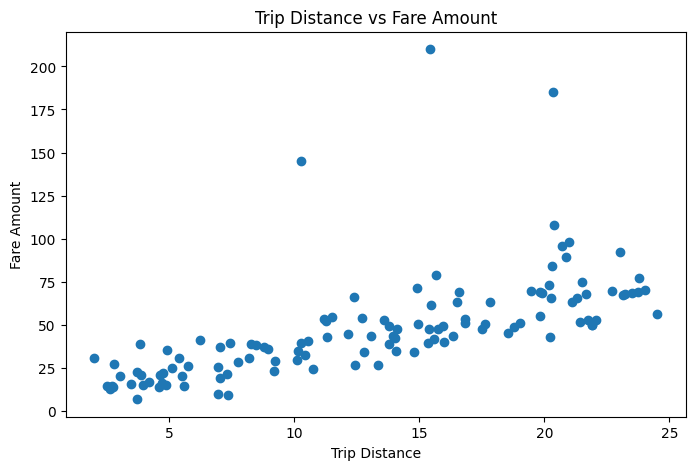

In [36]:
# creating graph

plt.figure(figsize=(8, 5))
plt.scatter(df["TripDistance"], df["FareAmount"])
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Trip Distance vs Fare Amount")
plt.show()

In [37]:
# Probability analysis

category_probability = df["RideCategory"].value_counts(normalize=True)

print("Ride Category Probabilities:")
print(category_probability)

Ride Category Probabilities:
RideCategory
Economy    0.516667
Premium    0.333333
Shared     0.150000
Name: proportion, dtype: float64


In [38]:
# peak-hour probability

peak_probability = (df["PeakHour"] == "Peak").mean()

print("Probability of a Peak-Hour Ride:", peak_probability)

Probability of a Peak-Hour Ride: 0.45


In [39]:
# Surge pricing analysis

surge_rating = df.groupby("SurgePricing")["CustomerRating"].mean()

print("Average Customer Rating by Surge Pricing:")
print(surge_rating)

Average Customer Rating by Surge Pricing:
SurgePricing
1.00    4.539600
1.10    4.651111
1.25    4.574000
1.50    4.479375
1.75    4.269091
2.00    4.452000
Name: CustomerRating, dtype: float64


In [40]:
# Revenue analysis

revenue_by_peak = df.groupby("PeakHour")["Revenue"].agg(
    ["count", "mean", "sum"]
)

display(revenue_by_peak)

,count,mean,sum
PeakHour,,,
Non-Peak,66,51.906818,3425.85
Peak,54,53.739074,2901.91


In [41]:
# Outlier detection

Q1 = df["FareAmount"].quantile(0.25)
Q3 = df["FareAmount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["FareAmount"] < lower_bound) |
    (df["FareAmount"] > upper_bound)
]

print("Number of fare outliers:", len(outliers))
display(outliers)

Number of fare outliers: 3


,TripID,TripDistance,FareAmount,RideCategory,SurgePricing,CustomerRating,PeakHour,Revenue,RideDemand,WaitTime,DriverRating,CancellationRate
8,1009,10.29,145.0,Economy,1.0,5.00,Peak,154.94,108,6.0,4.66,0.048
57,1058,20.35,185.0,Premium,1.5,4.64,Non-Peak,186.79,40,10.2,4.56,0.044
103,1104,15.45,210.0,Shared,1.0,4.53,Non-Peak,211.67,80,5.6,3.95,0.027


In [42]:
# Covariance and correlation

print("Covariance Matrix:")
display(df[[
    "TripDistance",
    "FareAmount",
    "CustomerRating",
    "Revenue",
    "RideDemand"
]].cov())

Covariance Matrix:


,TripDistance,FareAmount,CustomerRating,Revenue,RideDemand
TripDistance,43.638245,125.777499,0.064628,126.654670,-8.987870
FareAmount,125.777499,922.217333,-0.069151,922.107570,-62.433968
CustomerRating,0.064628,-0.069151,0.080889,-0.042448,-0.133467
Revenue,126.654670,922.107570,-0.042448,936.172336,9.917501
RideDemand,-8.987870,-62.433968,-0.133467,9.917501,1117.324300


In [43]:

print("Correlation Matrix:")
display(df[[
    "TripDistance",
    "FareAmount",
    "CustomerRating",
    "Revenue",
    "RideDemand"
]].corr())

Correlation Matrix:


,TripDistance,FareAmount,CustomerRating,Revenue,RideDemand
TripDistance,1.000000,0.626979,0.034399,0.626628,-0.040704
FareAmount,0.626979,1.000000,-0.008006,0.992401,-0.061506
CustomerRating,0.034399,-0.008006,1.000000,-0.004878,-0.014039
Revenue,0.626628,0.992401,-0.004878,1.000000,0.009697
RideDemand,-0.040704,-0.061506,-0.014039,0.009697,1.000000


In [44]:
# Statistical hypothesis testing

economy = df[df["RideCategory"] == "Economy"]["FareAmount"]
premium = df[df["RideCategory"] == "Premium"]["FareAmount"]

t_stat, p_value = ttest_ind(economy, premium, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -4.287531484824738
P-value: 5.589094227876901e-05


In [45]:
# Chi-square test

table = pd.crosstab(
    df["RideCategory"],
    df["PeakHour"]
)

print("Contingency Table:")
display(table)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Contingency Table:


PeakHour,Non-Peak,Peak
RideCategory,,
Economy,32,30
Premium,23,17
Shared,11,7


Chi-square statistic: 0.6600050686072194
P-value: 0.718921911463222


In [46]:
# ANOVA

groups = [
    group["FareAmount"].values
    for _, group in df.groupby("RideCategory")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 7.776528107228681
P-value: 0.0006746411066786914
